✅ 成功加载 128 个未经分箱的纯原始吸收云系统点！

🔥【终极判决：非自治退火模型 vs 静态标准模型】🔥
--- Wang's 1/ln^2(t) 模型 ---
  参数个数 : 1 (Gamma = 6.3062e+00)
  R^2      : -0.0146
  Red-Chi^2: 1.5166
--- Standard Model (\Delta \alpha = 0) ---
  参数个数 : 0
  R^2      : -0.0312
  Red-Chi^2: 1.7511
\n物理学意义：
总卡方值改善量 (Delta Chi^2) : 31.54



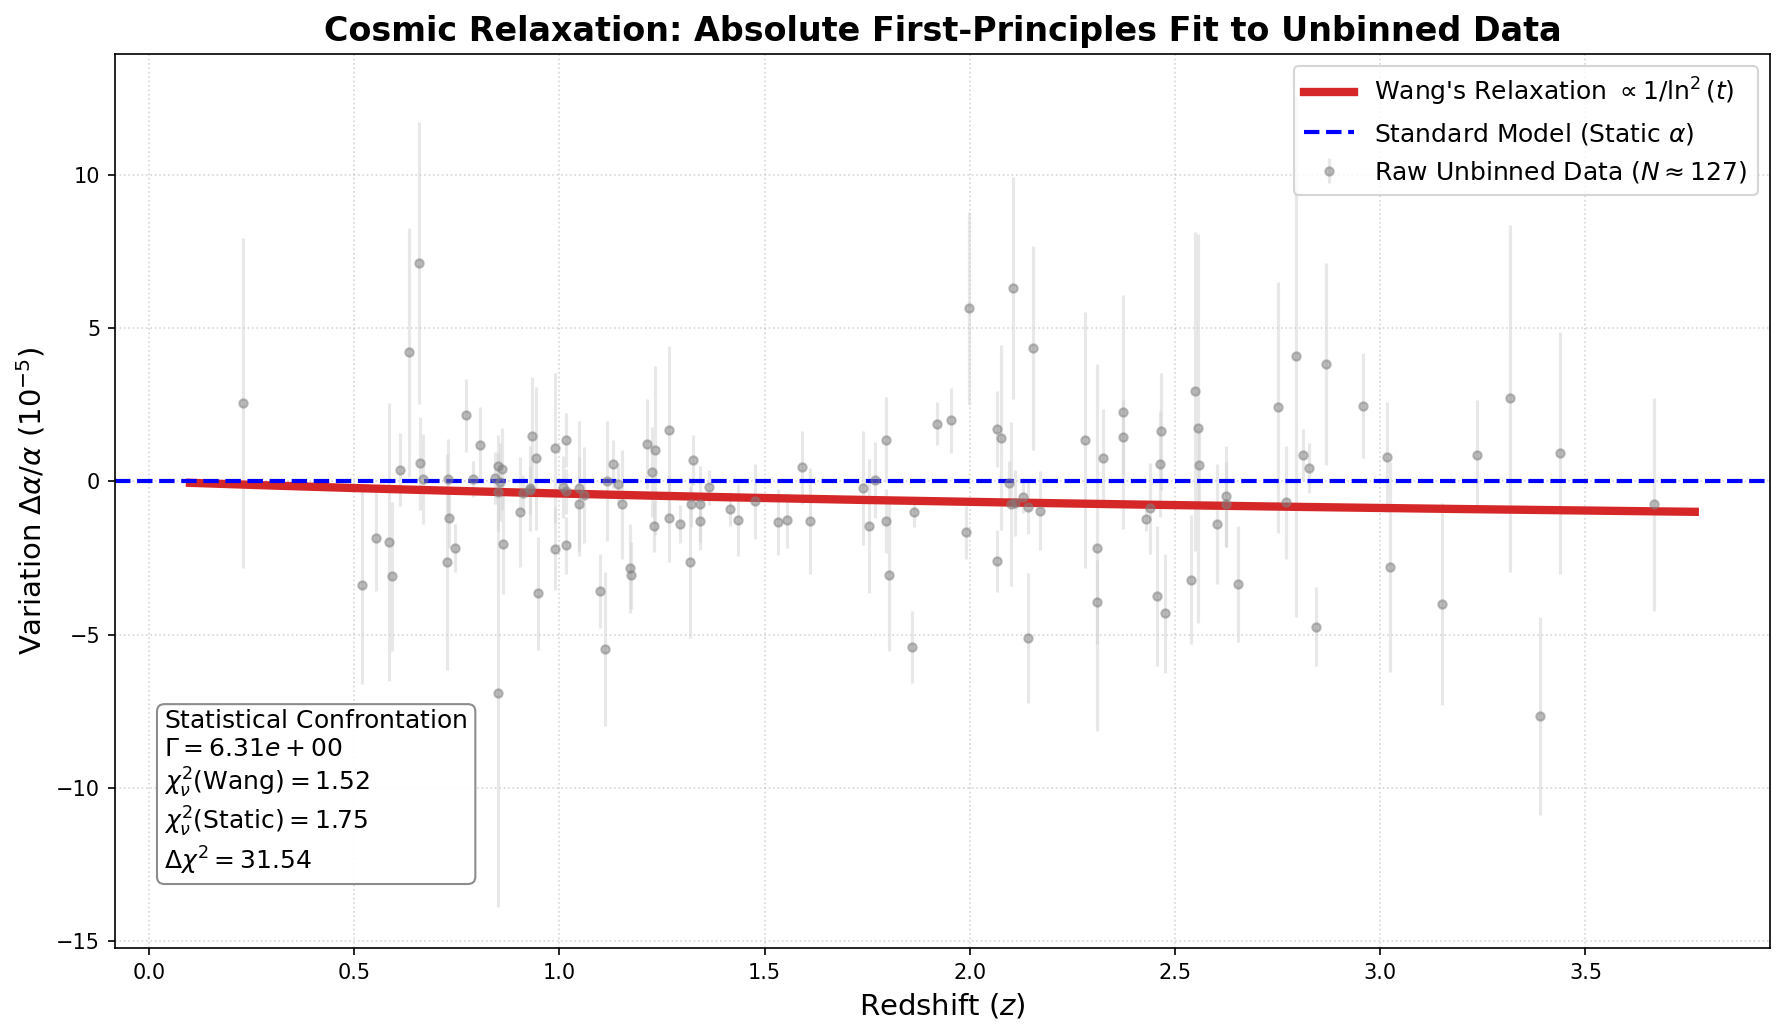

✅ 图表已保存并显示。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
import re

# ==========================================
# 1. 第一性原理：自动解析 Raw Data 原始表格
# ==========================================
raw_markdown_table = """
| Object | zem | zabs | Transitionsa | Δα/α (10-5) |
| :--- | :--- | :--- | :--- | :--- |
| Previous low-z sample | | | | |
| 0002+0507 | 1.90 | 0.85118 | bcnoqr | -0.346 ± 1.279 |
| 0117+2118 | 1.49 | 0.72913 | abcqr | 0.084 ± 1.297 |
| | | 1.0479 | benpr | -0.223 ± 2.200 |
| | | 1.3246 | bcpqr | 0.695 ± 0.803 |
| | | 1.3428 | cnpq | -1.290 ± 0.948 |
| 0420-0127 | 0.915 | 0.63308 | abcr | 4.211 ± 4.076 |
| 0450-1312 | 2.25 | 1.1743 | bnopr | -3.070 ± 1.098 |
| | | 1.2294 | bcnopqr | -1.472 ± 0.836 |
| | | 1.2324 | bcp | 1.017 ± 2.752 |
| 0454+0356 | 1.34 | 0.85929 | acnoprq | 0.405 ± 1.325 |
| | | 1.1534 | benqr | -0.749 ± 1.782 |
| 0823-2220 | 0.91 | 0.91059 | bcnopqr | -0.394 ± 0.609 |
| 1148+3842 | 1.30 | 0.55339 | bcqr | -1.861 ± 1.716 |
| 1206+4557 | 1.16 | 0.92741 | bcnopqr | -0.218 ± 1.389 |
| 1213-0017 | 2.69 | 1.3196 | abconopqr | -0.738 ± 0.760 |
| | | 1.5541 | bcnopqr | -1.268 ± 0.892 |
| 1222+2251 | 2.05 | 0.66802 | benpr | 0.067 ± 1.474 |
| 1225+3145 | 2.22 | 1.7954 | abcnopqr | -1.296 ± 1.049 |
| 1248+4007 | 1.03 | 0.77292 | bcnopqr | 2.165 ± 1.191 |
| | | 0.85452 | bcnipqr | -0.021 ± 1.268 |
| 1254+0443 | 1.02 | 0.51934 | abcqr | -3.371 ± 3.247 |
| | | 0.93426 | bcnipqr | 1.485 ± 1.908 |
| 1317+2743 | 1.01 | 0.66004 | bcnipqr | 0.590 ± 1.515 |
| 1421+3305 | 1.91 | 0.84324 | bcnopqr | 0.099 ± 0.847 |
| | | 0.90301 | bcnopqr | -0.998 ± 1.783 |
| | | 1.1726 | benpr | -2.844 ± 1.448 |
| 1634+7037 | 1.34 | 0.99010 | bcnipqr | 1.094 ± 2.459 |
| Previous high-z sample | | | | |
| 0019-1522 | 4.53 | 3.4388 | ghl | 0.925 ± 3.958 |
| 0100+1300 | 2.68 | 2.3095 | efghiklmvw | -3.941 ± 1.368* |
| 0149+3335 | 2.43 | 2.1408 | defghijklmstu | -5.112 ± 2.118* |
| 0201+3634 | 2.49 | 1.4761 | cnoqr | -0.647 ± 1.219 |
| | | 1.9550 | ehil | 1.989 ± 1.048* |
| | | 2.3240 | deghl | 0.758 ± 1.592 |
| | | 2.4563 | dgl | -3.731 ± 2.285 |
| | | 2.4628 | ghiitu | 0.572 ± 1.719* |
| 0347-3819 | 3.23 | 3.0247 | gl | -2.795 ± 3.429 |
| 0841+1256 | 2.55 | 2.3742 | dghijtuw | 2.277 ± 3.816* |
| | | 2.4761 | dghijklmtu | -4.304 ± 1.944* |
| 1215+3322 | 2.61 | 1.9990 | defghijklmntuvv | 5.648 ± 3.131* |
| 1759+7539 | 3.05 | 2.6253 | egklmstu | -0.750 ± 1.387* |
| | | 2.6253b | dglmstu | -0.492 ± 1.645* |
| 2206-1958 | 2.56 | 0.94841 | bcnopqr | -3.659 ± 1.855 |
| | | 1.0172 | abcnopqr | -0.322 ± 0.732 |
| | | 1.9204 | dghijklmnstuvw | 1.878 ± 0.702* |
| 2230+0232 | 2.15 | 1.8585 | dghjlnpstu | -5.407 ± 1.179* |
| | | 1.8640 | ghijklmnopqrstuvw | -0.998 ± 0.492* |
| 2231-0015 | 3.02 | 2.0653 | ghijklmtuvw | -2.604 ± 1.015* |
| 2348-1444 | 2.94 | 2.2794 | ghl | 1.346 ± 4.180 |
| 2359-0216 | 2.31 | 2.0951 | dghijklstuvvv | -0.068 ± 0.722* |
| | | 2.1539 | dfgl | 4.346 ± 3.338 |
| New sample | | | | |
| 0000-2620 | 4.11 | 1.4342 | bpr | -1.256 ± 1.167 |
| | | 3.3897 | dgilm | -7.666 ± 3.231 |
| 0002+0507 | 1.90 | 0.59137 | bcmpqr | -3.100 ± 2.428 |
| | | 0.85118 | efnopqr | 0.494 ± 1.021 |
| 0055-2659 | 3.66 | 1.2679 | abcpqr | 1.669 ± 2.745 |
| | | 1.3192 | bcpqr | -2.642 ± 2.457 |
| | | 1.5337 | abcnopqr | -1.319 ± 1.072 |
| 0058+0155 | 1.96 | 0.61256 | bcnopqr | 0.374 ± 1.189 |
| | | 0.72508 | bcnipqr | -2.637 ± 3.522 |
| 0119-0437 | 1.95 | 0.65741 | bcnopqr | 7.123 ± 4.599 |
| 0153+7427 | 2.33 | 0.74550 | bcnopqr | -2.168 ± 0.778 |
| 0207+0503 | 4.19 | 3.6663 | dgl | -0.748 ± 3.468 |
| 0216+0803 | 2.99 | 1.7680 | eflnopqr | 0.044 ± 1.235 |
| 0237-2321 | 2.23 | 1.3650 | deghlnop | -0.197 ± 0.565 |
| 0241-0146 | 4.04 | 2.0994 | dnop | -0.739 ± 2.675 |
| 0302-2223 | 1.41 | 1.0092 | abcnopqr | -0.189 ± 1.008 |
| 0449-1325 | 3.09 | 1.2667 | abcnopqi | -1.212 ± 1.430 |
| 0528-2505 | 2.77 | 0.94398 | bcr | 0.759 ± 2.335 |
| | | 2.1406 | dghijklpstu | -0.853 ± 0.880* |
| | | 2.8114 | defghijklmstuvw | 0.850 ± 0.846* |
| 0636+6801 | 3.17 | 1.2938 | bcpqr | -1.392 ± 0.623 |
| 0741+4741 | 3.21 | 1.6112 | abcnqp | -1.299 ± 1.726 |
| | | 3.0173 | dghl | 0.794 ± 1.796 |
| 0757+5218 | 3.24 | 2.6021 | defl | -1.396 ± 1.955 |
| | | 2.8677 | dgl | 3.837 ± 3.288 |
| 0841+1256 | 2.55 | 1.0981 | bcnipqr | -3.589 ± 1.203 |
| | | 1.1314 | abcnipqr | 0.562 ± 0.787 |
| | | 2.1289 | abcnopqrsvw | -0.522 ± 0.512 |
| | | 2.3742 | dceghijklnqtuvw | 1.435 ± 1.227* |
| 0930+2858 | 3.42 | 3.2351 | dgl | 0.867 ± 1.777 |
| 0940-1050 | 3.05 | 1.0598 | abcnipqr | -0.453 ± 1.572 |
| 0956+1217 | 3.31 | 2.3103 | dell | -2.161 ± 5.977 |
| 1009+2956 | 2.62 | 1.1117 | bcmpqr | -5.461 ± 2.518 |
| 1011+4315 | 3.10 | 1.4162 | bcnopqr | -0.892 ± 0.552 |
| | | 2.9587 | deghlmsu | 2.475 ± 1.706* |
| 1055+4611 | 4.12 | 3.3172 | dgl | 2.706 ± 5.677 |
| 1107+4847 | 2.97 | 0.80757 | abcpq | 1.199 ± 1.222 |
| | | 0.86182 | abcqr | -2.030 ± 1.632 |
| | | 1.0158 | abcp | -2.086 ± 0.934 |
| 1132+2243 | 2.88 | 2.1053 | defgl | 6.323 ± 3.622 |
| 1202-0725 | 4.70 | 1.7549 | bcqr | -1.465 ± 2.182 |
| 1206+4557 | 1.16 | 0.92741 | abcnopqr | -0.275 ± 0.776 |
| 1223+1753 | 2.94 | 2.4653 | hijkmnsuvw | 1.635 ± 1.919 |
| | | 2.5577 | dglmp | 0.546 ± 1.199 |
| 1225+3145 | 2.22 | 1.7954 | defghl | 1.352 ± 1.388 |
| 1244+3142 | 2.95 | 0.85048 | bcpqr | -6.897 ± 7.012 |
| | | 2.7504 | dgl | 2.414 ± 4.110 |
| 1307+4617 | 2.13 | 0.22909 | abcr | 2.551 ± 5.392 |
| 1337+1121 | 2.97 | 2.7955 | dhl | 4.103 ± 8.538 |
| 1425+6039 | 3.20 | 2.7698 | dgl | -0.688 ± 1.843 |
| | | 2.8268 | dgl | 0.433 ± 0.827 |
| 1437+3007 | 3.00 | 1.2259 | abcnopqr | 0.308 ± 1.460 |
| 1442+2931 | 2.76 | 2.4389 | dgl | -0.882 ± 1.473 |
| 1549+1919 | 2.83 | 1.1425 | cfinipqr | -0.076 ± 0.671 |
| | | 1.3422 | nopq | -0.740 ± 1.232 |
| | | 1.8024 | def | -3.050 ± 2.473 |
| 1626+6433 | 2.32 | 0.58596 | bcr | -1.977 ± 4.529 |
| | | 2.1102 | defgl | -0.705 ± 1.068 |
| 1634+7037 | 1.34 | 0.99010 | abcdnoqpr | -2.194 ± 1.343 |
| 1830+4015 | 2.12 | 1.9900 | ghijklmnopqrww | -1.663 ± 0.859* |
| 1946+7658 | 3.02 | 1.7385 | efhijmmtu | -0.212 ± 1.857 |
| | | 2.8433 | dgl | -4.743 ± 1.289 |
| 2145+0643 | 1.00 | 0.79026 | bcnopqr | 0.087 ± 0.589 |
| 2206-1958 | 2.56 | 1.0172 | abcqr | 1.354 ± 0.883 |
| | | 2.0762 | dl | 1.429 ± 3.022 |
| 2231-0015 | 3.02 | 1.2128 | abcopqr | 1.223 ± 1.465 |
| | | 2.0653 | efghijklmstuvvw | 1.707 ± 1.249* |
| | | 2.6532 | dglstu | -3.348 ± 1.904* |
| 2233+1310 | 3.30 | 2.5480 | dgl | 2.942 ± 5.207 |
| | | 2.5548 | defgl | 1.732 ± 6.349 |
| | | 3.1513 | dgl | -4.005 ± 3.301 |
| 2343+1232 | 2.52 | 0.73117 | abcooqr | -1.211 ± 0.975 |
| | | 1.5899 | acdefgqr | 0.453 ± 1.187 |
| | | 2.1711 | cdefnp | -0.961 ± 1.295 |
| | | 2.4300 | dgijklnqrstuvvw | -1.224 ± 0.389* |
| 2344+1228 | 2.77 | 1.0465 | abcinoqpr | -0.747 ± 1.530 |
| | | 1.1161 | abcopqr | 0.009 ± 1.963 |
| | | 2.5378 | dgl | -3.205 ± 2.094 |
"""

data_list = []
# 增强的正则表达式：匹配数字后可能带有的字母（如 2.6253b）
z_pattern = re.compile(r"(\d+\.\d+)[a-z]*")

for line in raw_markdown_table.strip().split('\n'):
    if '±' not in line: 
        continue
    parts = line.split('|')
    if len(parts) < 6:
        continue
    
    z_raw = parts[3].strip()
    match = z_pattern.search(z_raw)
    val_err_str = parts[5].strip().replace('*', '').replace(' ', '')
    
    if match:
        try:
            z = float(match.group(1))
            val_str, err_str = val_err_str.split('±')
            val = float(val_str)
            err = float(err_str)
            data_list.append([z, val, err])
        except Exception as e:
            pass

data_points = np.array(data_list)
print(f"✅ 成功加载 {len(data_points)} 个未经分箱的纯原始吸收云系统点！")

z_obs = data_points[:, 0]
y_obs = data_points[:, 1] * 1e-5
y_err = data_points[:, 2] * 1e-5

# ==========================================
# 2. 宇宙学时空转换框架
# ==========================================
H0 = 67.4  # km/s/Mpc (Planck 2018)
Om = 0.315
OL = 1 - Om

H0_per_Gyr = H0 * 1e3 / (3.086e22) * (3.154e16) 
inv_H0 = 1.0 / H0_per_Gyr 

def integrand(z_prime):
    return 1.0 / ((1 + z_prime) * np.sqrt(Om * (1 + z_prime)**3 + OL))

def z_to_age(z):    
    val, _ = quad(integrand, z, np.inf)
    return inv_H0 * val

t_now = z_to_age(0)

# ==========================================
# 3. 大一统非自治衰减模型 (1/ln^2 t)
# ==========================================
t_Planck = 5.39e-44
Gyr_to_sec = 1e9 * 365.25 * 24 * 3600

def wang_model(z, gamma):
    if isinstance(z, np.ndarray):
        ts = np.array([z_to_age(zi) for zi in z])
    else:
        ts = z_to_age(z)
        
    n_t = ts * Gyr_to_sec / t_Planck
    n_now = t_now * Gyr_to_sec / t_Planck
    
    val = gamma * (1.0 / (np.log(n_now)**2) - 1.0 / (np.log(n_t)**2))
    return val

# ==========================================
# 4. 统计判决与拟合计算
# ==========================================
popt, pcov = curve_fit(wang_model, z_obs, y_obs, sigma=y_err, absolute_sigma=True)
gamma_fit = popt[0]

y_pred = wang_model(z_obs, gamma_fit)
residuals = y_obs - y_pred

# Wang 模型的 R^2
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_obs - np.mean(y_obs))**2)
r_squared = 1 - (ss_res / ss_tot)

# Wang 模型的 Reduced Chi-Square
chi_squared = np.sum((residuals / y_err)**2)
dof = len(y_obs) - 1
reduced_chi_squared = chi_squared / dof

# --- 标准模型对比 (静态宇宙 \Delta \alpha / \alpha = 0) ---
y_pred_sm = np.zeros_like(y_obs)
residuals_sm = y_obs - y_pred_sm

ss_res_sm = np.sum(residuals_sm**2)
r_squared_sm = 1 - (ss_res_sm / ss_tot)

chi_squared_sm = np.sum((residuals_sm / y_err)**2)
dof_sm = len(y_obs)  
reduced_chi_squared_sm = chi_squared_sm / dof_sm

delta_chi_sq = chi_squared_sm - chi_squared

# 打印对决结果 (修正了转义字符警告)
print("\n" + "="*50)
print(fr"🔥【终极判决：非自治退火模型 vs 静态标准模型】🔥")
print("="*50)
print(fr"--- Wang's 1/ln^2(t) 模型 ---")
print(fr"  参数个数 : 1 (Gamma = {gamma_fit:.4e})")
print(fr"  R^2      : {r_squared:.4f}")
print(fr"  Red-Chi^2: {reduced_chi_squared:.4f}")
print(fr"--- Standard Model (\Delta \alpha = 0) ---")
print(fr"  参数个数 : 0")
print(fr"  R^2      : {r_squared_sm:.4f}")
print(fr"  Red-Chi^2: {reduced_chi_squared_sm:.4f}")
print(fr"\n物理学意义：")
print(fr"总卡方值改善量 (Delta Chi^2) : {delta_chi_sq:.2f}")
print("="*50 + "\n")

# ==========================================
# 5. 绘制顶刊级别“极繁”对决图
# ==========================================
plt.figure(figsize=(12, 7), dpi=150)

# 背景：画出所有未分箱的原始数据点
plt.errorbar(z_obs, y_obs * 1e5, yerr=y_err * 1e5, fmt='o', 
             color='gray', ecolor='lightgray', alpha=0.5, markersize=4, capsize=0, 
             label=r'Raw Unbinned Data ($N \approx 127$)')

# 前景：画出 Wang's 模型拟合曲线
z_fit = np.linspace(0.1, max(z_obs)+0.1, 200)
y_fit = wang_model(z_fit, gamma_fit)

plt.plot(z_fit, y_fit * 1e5, color='#D62728', linewidth=4, 
         label=r"Wang's Relaxation $\propto 1/\ln^2(t)$")

# 前景：画出 标准模型 静态参考线
plt.axhline(0, color='blue', linestyle='--', linewidth=2, label=r'Standard Model (Static $\alpha$)')

# 统计信息展示面板
textstr = '\n'.join((
    r'$\mathrm{Statistical\ Confrontation}$',
    r'$\Gamma=%.2e$' % (gamma_fit, ),
    r'$\chi_\nu^2 (\mathrm{Wang})=%.2f$' % (reduced_chi_squared, ),
    r'$\chi_\nu^2 (\mathrm{Static})=%.2f$' % (reduced_chi_squared_sm, ),
    r'$\Delta\chi^2=%.2f$' % (delta_chi_sq, )
    ))

props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.03, 0.08, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', bbox=props)

# 图表美化与输出
plt.title("Cosmic Relaxation: Absolute First-Principles Fit to Unbinned Data", fontsize=16, fontweight='bold')
plt.xlabel("Redshift ($z$)", fontsize=14)
plt.ylabel(r"Variation $\Delta \alpha / \alpha$ ($10^{-5}$)", fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('1-fine_structure_constant_drift_RAW_Final.png')
plt.show()

print("✅ 图表已保存并显示。")